# Librerias necesarias para el preprocesamiento de datos


In [584]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

## Carga del dataset local e información útil de los datos
Se carga el dataset de manera local y se consulta los tipos de datos de cada característica del dataset

*El Dataset se encuentra sesgado 4 a 1 en las clases objetivo*

In [585]:
telcoCustomers = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
telcoCustomers.info()
print(telcoCustomers.Churn.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##  Valores nulos por caracteristica en el dataset

Aunque en la sumatoria pueda mostrar que no haya valores nulos/NaN hay que verificar el tipo de dato de cada caracteristica del dataframe para poder tratar datos numericos identificados como objetos haciendo engañoso a un NaN como un espacio en blanco

In [587]:
print(telcoCustomers.isna().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [588]:
df = telcoCustomers.copy()

In [589]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors= 'coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors= 'coerce')

print('total de datos nulos:\n', df[['TotalCharges', 'MonthlyCharges']].isnull().sum())
df.dropna(inplace=True)

# dfTargetYes= df[df['Churn']=='Yes']
# dfTargetNo= df[df['Churn']=='No']
# dfChurnNo = dfTargetNo.sample(len(dfTargetYes), random_state=1)
# dfBalanceado = pd.concat([dfChurnNo, dfTargetYes]) 
# target = dfBalanceado['Churn']
# data = dfBalanceado.drop(columns=['Churn', 'customerID'])

target = df['Churn']
data = df.drop(columns=['Churn', 'customerID'])

total de datos nulos:
 TotalCharges      11
MonthlyCharges     0
dtype: int64


In [590]:
print(data.isna().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [591]:

data['MultipleLines'] = data['MultipleLines'].replace('No phone service', 'No')    

columnasInternet = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity',]

for col in columnasInternet:
    data[col]= data[col].replace('No internet service', 'No')

for col in data.select_dtypes(include='object').columns:
    if col != 'customerID':
        print(f"--- Columna: {col} ---")
        print(data[col].value_counts(dropna=False).head(5))
        print("\n")


--- Columna: gender ---
gender
Male      3549
Female    3483
Name: count, dtype: int64


--- Columna: Partner ---
Partner
No     3639
Yes    3393
Name: count, dtype: int64


--- Columna: Dependents ---
Dependents
No     4933
Yes    2099
Name: count, dtype: int64


--- Columna: PhoneService ---
PhoneService
Yes    6352
No      680
Name: count, dtype: int64


--- Columna: MultipleLines ---
MultipleLines
No     4065
Yes    2967
Name: count, dtype: int64


--- Columna: InternetService ---
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64


--- Columna: OnlineSecurity ---
OnlineSecurity
No     5017
Yes    2015
Name: count, dtype: int64


--- Columna: OnlineBackup ---
OnlineBackup
No     4607
Yes    2425
Name: count, dtype: int64


--- Columna: DeviceProtection ---
DeviceProtection
No     4614
Yes    2418
Name: count, dtype: int64


--- Columna: TechSupport ---
TechSupport
No     4992
Yes    2040
Name: count, dtype: int64


--- Columna: Str

## Identificar el tipo de codificación para cada columna del dataset
Cada tipo de dato ya sea numérico o categórico requiere una codificación especifica para el modelo de clasificación 

In [592]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [593]:
caracteristicasNumericas = ['tenure', 'MonthlyCharges', 'TotalCharges']
caracteristicasNominales = ['PaymentMethod', 'InternetService']
caracteristicasBinarias= ['gender' ,'SeniorCitizen' , 'Partner' ,'StreamingMovies', 
                                'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 
                                'OnlineSecurity' ,'Dependents', 'PhoneService', 'MultipleLines', 'PaperlessBilling']
caracteristicasOrdinales =['Contract']

contractOrden = [['Month-to-month', 'One year', 'Two year']]

## Imputer y Column Transformer con Pipelines
No se hace uso de imputers debido a que se revisó previamente que las categorías no contuvieran cadenas vacias ni que los datos numéricos fueran NaN

In [594]:
transformadorNumerico = Pipeline(
    steps=[
        # ('imputer', SimpleImputer(strategy= 'median')),
        ('scalar', StandardScaler())        
    ]
)

In [595]:
transformadorOrdinal = Pipeline(
    steps=[
        ('ordinal', OrdinalEncoder(categories=contractOrden))         
    ]
)

In [596]:
transformadorNominal = Pipeline(
    steps=[
        ('oneHot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [597]:
transformadorBinario= Pipeline(
        steps=[
            ('binario', OrdinalEncoder())
        ]
    )

## Preprocesamiento de los datos
Se realiza un preprocesamiento de los datos con un pipeline y posteriormente se pasa al modelo el dataset limpio y normalizado


In [598]:
preprocesador = ColumnTransformer(
    transformers=[
        ('binario', transformadorBinario, caracteristicasBinarias),
        ('numerico', transformadorNumerico, caracteristicasNumericas),
        ('ordinal', transformadorOrdinal, caracteristicasOrdinales), 
        ('nominal', transformadorNominal, caracteristicasNominales)
    ]
)

## Modelos

El árbol de desición de sklearn solo permite implementar árboles binarios con distintos modos de hallar el nodo raíz y las ramas, usando entropía o gini.

In [599]:
arbolDesicion = DecisionTreeClassifier(random_state=1,criterion='entropy', class_weight='balanced', max_depth=3)

In [600]:
pipeline = Pipeline(
    steps=[
        ('preprocesador', preprocesador),('arbol', arbolDesicion)
    ]
)
Xtrain, Xtest, Ytrain, Ytest = train_test_split(data, target, random_state=42 , test_size=0.20)
pipeline.fit(Xtrain, Ytrain)

yPred= pipeline.predict(Xtest)

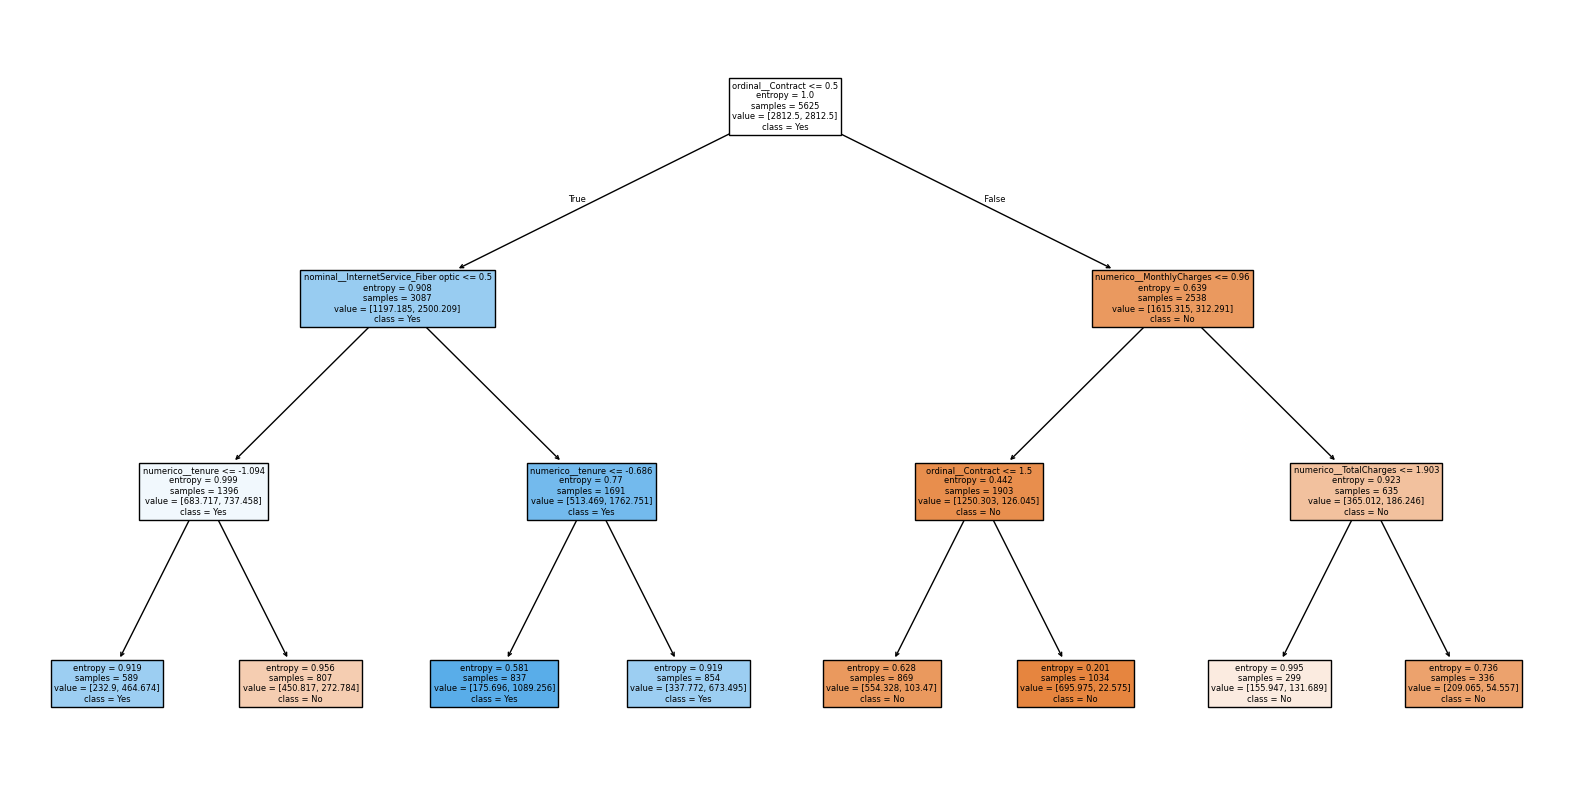

In [601]:
modelo_final = pipeline.named_steps['arbol']

nombreColumnas = pipeline.named_steps['preprocesador'].get_feature_names_out()
plt.figure(figsize=(20,10))
plot_tree(
    pipeline.named_steps['arbol'], 
    feature_names= nombreColumnas, class_names=['No', 'Yes'],
    filled=True, max_depth=3) 
plt.show()

## Explicación

Contract son 3 de manera ordinal y su entropia es 1, los separó y combinó para ver cuál separaba mejor en base al menor sesgo que se puede ver con la entropía, luego se busco al grupo cuales eran los dos con mayor ganancia de informacion o los que mejor separan la información del total que les da Contract y lo mismo con sus hijos pero ya no usando el dataset global si no el que va dejando el padre.



## Evaluación del modelo

Se hace uso de métricas para medir la eficiencia del modelo para clasificar clientes que van a cancelar de aquellos que no para tomar desición estrategica con ellos. 

In [602]:
print(f"Accuracy {accuracy_score(Ytest, yPred)}: ")

Accuracy 0.7235252309879175: 


In [603]:
user = data.iloc[[4]] 

prediccion = pipeline.predict(user)[0]

print(f"Predicción: {prediccion}")

Predicción: Yes


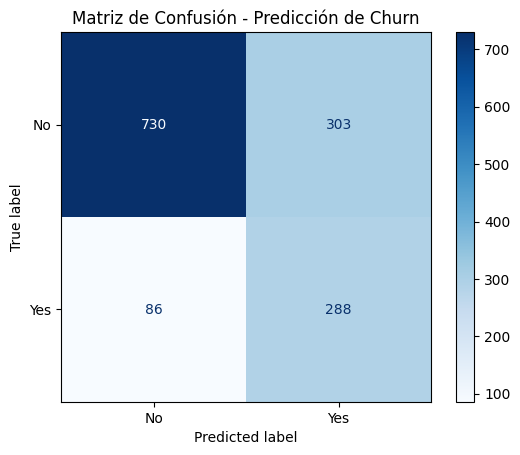

In [604]:
cm = confusion_matrix(Ytest, yPred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matriz de Confusión - Predicción de Churn")
plt.show()

## Métricas

 * La presición nos dice qué porcentaje de individuos acertó con una clase 
 * El recall nos dice qué porcentaje el porcentaje de aciertos o verdaderos positivos por clase
 * El f1-score es la media armónica de presición y recall 

In [605]:
print(classification_report(Ytest, yPred))

              precision    recall  f1-score   support

          No       0.89      0.71      0.79      1033
         Yes       0.49      0.77      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407

